In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from collections import Counter

**Load Data**

In [5]:
df_original = pd.read_csv('Children Recode_final.csv')
df_original['Malnurished'] = df_original[['Underweight', 'Stunting', 'Wasting']].max(axis=1)
df = df_original.drop(['Underweight', 'Stunting', 'Wasting'], axis = 1)
df.head()


,Child_age,Mother_education,Age_first_sex,Pregnancy_terminated,Wealth_index,Place_residence,BMI,Children_under5,Total_children_ever_born,Child_sex,...,Ethnicity_2,Ethnicity_3,Ethnicity_4,Ethnicity_5,Ethnicity_6,Ethnicity_7,Ethnicity_8,Ethnicity_9,Ethnicity_10,Malnurished
0,17,1,14,0,1,2,22.00,1,1,2,...,1,0,0,0,0,0,0,0,0,0
1,40,2,17,1,2,2,25.10,2,2,1,...,0,0,0,0,0,0,1,0,0,1
2,59,2,17,1,2,2,25.10,2,2,2,...,0,0,0,0,0,0,1,0,0,1
3,55,2,17,0,2,2,21.53,1,1,2,...,0,0,0,0,0,0,1,0,0,1
4,14,1,16,0,1,2,28.03,1,1,1,...,0,0,0,0,0,0,1,0,0,0


In [6]:
df.shape

(2239, 35)

**Train-test Split**

In [7]:
X = df.drop(columns=['Malnurished'])
y = df['Malnurished']

# Train-test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state= 42)

**Standard Scaler**

In [8]:
columns_to_scale = ['Child_age', 'Age_first_sex', 'BMI', 'Mother_age_current', 'Mother_age_at_first_birth']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test_scaled[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

In [9]:
X_train_scaled.head()

,Child_age,Mother_education,Age_first_sex,Pregnancy_terminated,Wealth_index,Place_residence,BMI,Children_under5,Total_children_ever_born,Child_sex,...,Religion_5,Ethnicity_2,Ethnicity_3,Ethnicity_4,Ethnicity_5,Ethnicity_6,Ethnicity_7,Ethnicity_8,Ethnicity_9,Ethnicity_10
1582,1.313051,2,-0.690976,1,1,2,-0.810367,2,2,2,...,0,0,0,0,1,0,0,0,0,0
2165,1.487901,1,-0.074979,0,5,1,0.569265,2,2,1,...,0,0,0,1,0,0,0,0,0,0
1387,-1.542832,2,1.465013,1,5,1,0.817704,0,2,1,...,0,0,0,1,0,0,0,0,0,0
178,1.604467,2,0.541018,0,3,2,2.184122,1,2,2,...,0,0,0,0,1,0,0,0,0,0
478,1.138201,0,-0.998974,1,4,1,0.963068,1,1,2,...,0,0,0,0,0,0,0,0,0,1


**Visualize the PCA Results**

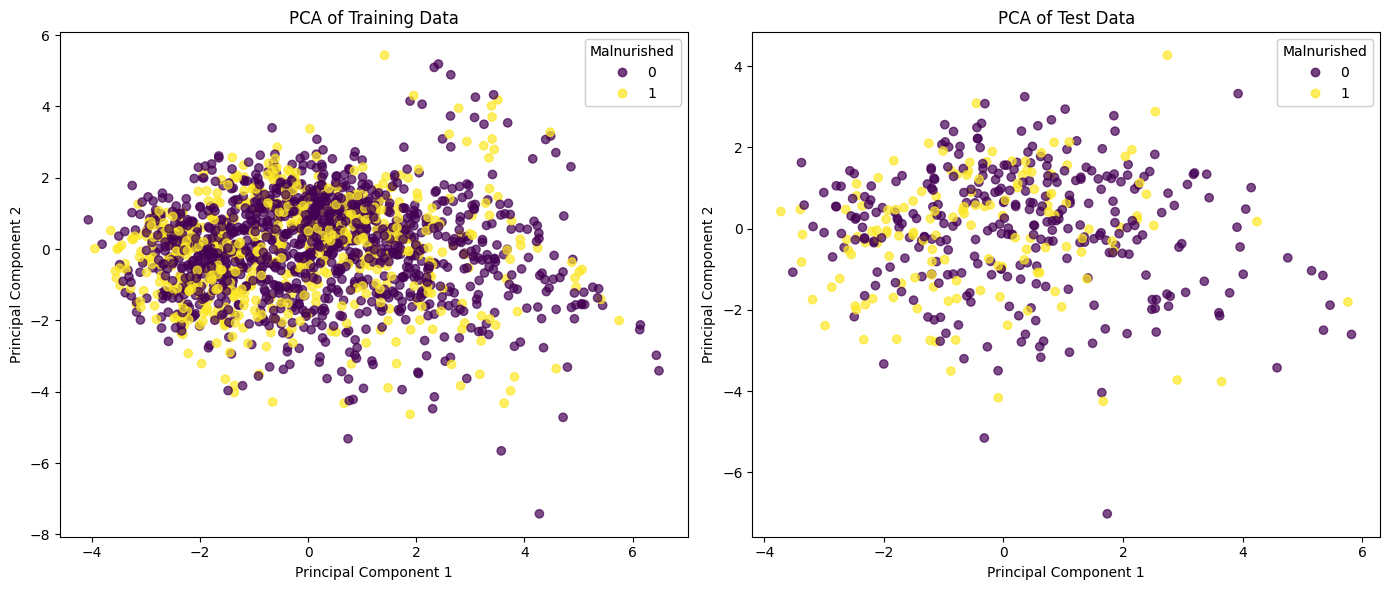

In [18]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for training data
scatter_train = axes[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
                                c=y_train, cmap='viridis', alpha=0.7)
axes[0].set_title("PCA of Training Data")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
legend1 = axes[0].legend(*scatter_train.legend_elements(), title="Malnurished")
axes[0].add_artist(legend1)

# Plot for test data
scatter_test = axes[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1], 
                               c=y_test, cmap='viridis', alpha=0.7)
axes[1].set_title("PCA of Test Data")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")
legend2 = axes[1].legend(*scatter_test.legend_elements(), title="Malnurished")
axes[1].add_artist(legend2)

plt.tight_layout()
plt.show()

**Balancing using SMOTE**

In [11]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print('Before SMOTE: ', Counter(y_train))
print('After SMOTE: ', Counter(y_train_sm))

Before SMOTE:  Counter({0: 1175, 1: 616})
After SMOTE:  Counter({1: 1175, 0: 1175})


**Cross-validation for Best k**

In [12]:
k_values = range(1, 31)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_sm, y_train_sm, cv = 10, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = k_values[np.argmax(cv_scores)]
print(f"Best k after balancing: {best_k}, Accuracy: {max(cv_scores):.4f}")

Best k after balancing: 2, Accuracy: 0.7366


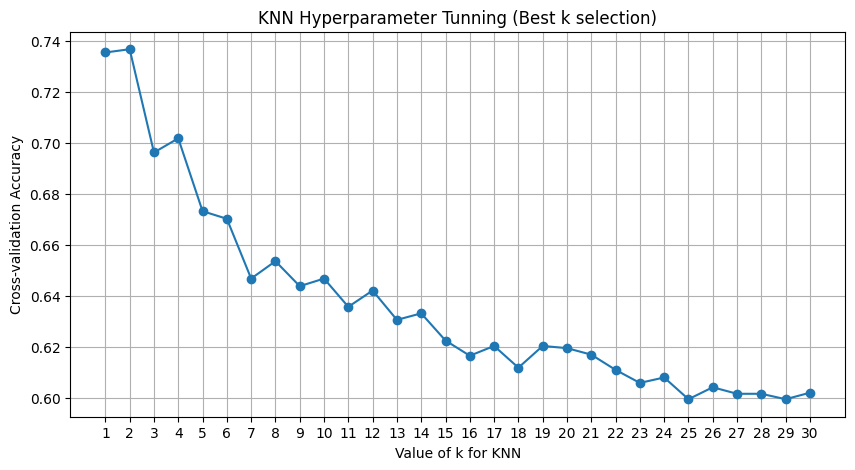

In [13]:
plt.figure(figsize=(10,5))
plt.plot(k_values, cv_scores, marker = 'o')
plt.xlabel('Value of k for KNN')
plt.ylabel('Cross-validation Accuracy')
plt.title('KNN Hyperparameter Tunning (Best k selection)')
plt.xticks(range(1,31,1))
plt.grid(True)
plt.show()

**Model Fit**

In [14]:
knn_combined = KNeighborsClassifier(n_neighbors=2)
knn_combined.fit(X_train_sm, y_train_sm)
y_predict = knn_combined.predict(X_test)

print(accuracy_score(y_test, y_predict))
pd.crosstab(y_test, y_predict)


0.6316964285714286


col_0,0,1
Malnurished,,
0,243,63
1,102,40


**Model's Performance**

In [15]:
# Classification Report
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.70      0.79      0.75       306
           1       0.39      0.28      0.33       142

    accuracy                           0.63       448
   macro avg       0.55      0.54      0.54       448
weighted avg       0.60      0.63      0.61       448



In [16]:
# ROC-AUC Score
auc = roc_auc_score(y_test, knn_combined.predict_proba(X_test)[:,1])
print(f'ROC-AUC Score: {auc:.4f}')

ROC-AUC Score: 0.5419
